In [ ]:
import pandas as pd
import numpy as np


def generate_csv_files():
    sizes = [1000, 10000, 100000, 1000000]
    columns = ['A', 'B', 'C', 'D', 'E']
    os.makedirs("csv_files", exist_ok=True)

    for size in sizes:
        data = {col: np.random.rand(size) for col in columns}
        df = pd.DataFrame(data)
        df.to_csv(f"csv_files/data_{size}.csv", index=False)

generate_csv_files()


In [ ]:
from codecarbon import EmissionsTracker
import pandas as pd
import os

def measure_emissions():
    sizes = [1000, 10000, 100000, 1000000]
    columns = ['A', 'B', 'C', 'D', 'E']
    results = []

    for size in sizes:
        file_path = f"csv_files/data_{size}.csv"
        for n_cols in range(1, 6):  # Lire 1 à 5 colonnes
            tracker = EmissionsTracker(log_level="error")
            tracker.start()
            df = pd.read_csv(file_path, usecols=columns[:n_cols])
            emissions = tracker.stop()
            results.append({
                "size": size,
                "num_columns": n_cols,
                "emissions": emissions
            })

    return pd.DataFrame(results)

df_results = measure_emissions()
df_results.to_csv("emissions_summary.csv", index=False)


[codecarbon WARNING @ 11:32:16] Multiple instances of codecarbon are allowed to run at the same time.


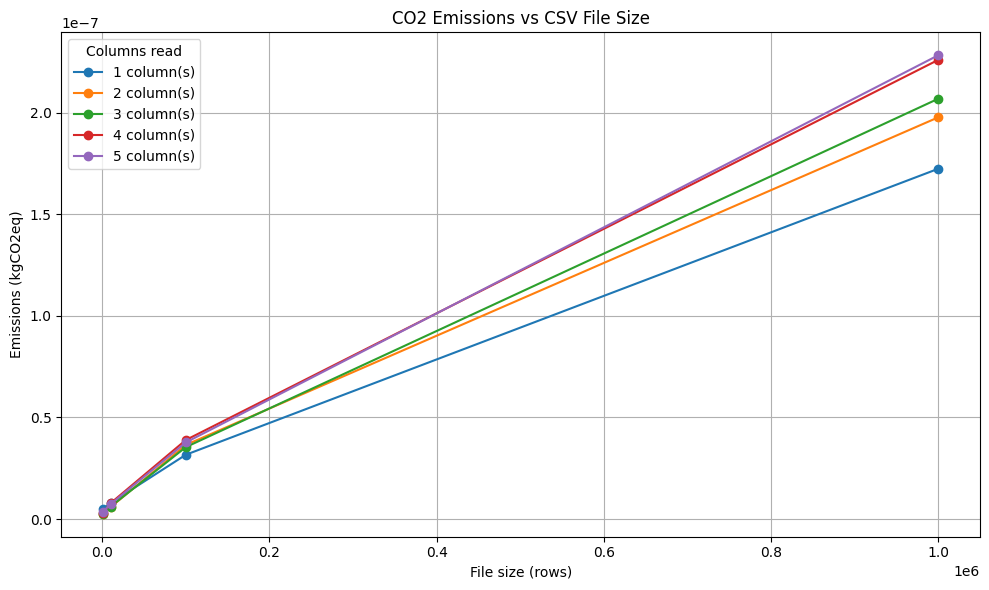

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("emissions_summary.csv")

plt.figure(figsize=(10, 6))

for n in range(1, 6):
    subset = df[df['num_columns'] == n]
    plt.plot(subset['size'], subset['emissions'], marker='o', label=f'{n} column(s)')

plt.xlabel("File size (rows)")
plt.ylabel("Emissions (kgCO2eq)")
plt.title("CO2 Emissions vs CSV File Size")
plt.legend(title="Columns read")
plt.grid(True)
plt.tight_layout()
plt.show()
